In [1]:
import pybamm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from scipy import constants
from pybamm import Scalar

current_directory = os.getcwd()

parameter_values = pybamm.ParameterValues("OKane2022") # 
options = {"thermal": "lumped","lithium plating": "irreversible","SEI":"ec reaction limited", "SEI film resistance":"average", "SEI porosity change": "true","loss of active material": "stress-driven","particle mechanics":"swelling only"}

model = pybamm.lithium_ion.SPM(options=options)

In [2]:
#thermal parameters update
parameter_values.update({"Negative electrode OCP entropic change [V.K-1]": -0.0002,
                         "Positive electrode OCP entropic change [V.K-1]": -0.0004,
                         "Contact resistance [Ohm]": 0.001,
                        })

In [3]:
def ec_diffusivity(T_amb):
    D_sj = 2.5e-22*4*10*3 
    EaD = 50000
    arrhenius = np.exp(EaD / pybamm.constants.R *(1/ 298.15 - 1/ T_amb))
    return D_sj * arrhenius
parameter_values.update({"EC diffusivity [m2.s-1]": ec_diffusivity})

In [4]:
#sei parameters update
parameter_values.update({"SEI kinetic rate constant [m.s-1]": 1e-12*0.002*10*3}) 

In [5]:
# LAM parameters update

parameter_values.update({"Positive electrode LAM constant proportional term [s-1]": 0.1*0.5*1.5/3600,
                         "Negative electrode LAM constant proportional term [s-1]": 0.5*0.5*1.5/3600,
                         
                         "Positive electrode LAM constant exponential term": 2.0*1.1,
                         "Negative electrode LAM constant exponential term": 2.0*1.1,
                         
                         })






In [6]:
#Plating paremeters update
parameter_values.update({
                        "Lithium plating kinetic rate constant [m.s-1]": 1e-09*0.0001,
                        
                        })


In [7]:
current_directory

'/home/ganmad/batterycode/pybammlocal/PyBaMMlocal/wip'

In [8]:
from itertools import product


temp_list = [10, 25, 45] #25,
crate_list = [0.1, 0.3, 1] #,[0.1,0.3, 1]
soc_list = [10, 60, 100] #,[10, 60, 100] 
dod_list = [50, 70, 90] #60, 70,[50, 70, 90]

all_cases = list(product(temp_list, crate_list, soc_list, dod_list))

df = pd.DataFrame(all_cases,columns = ["Temperature", "C_rate", "SoC", "DoD"])
df.insert(0, "Case", range(1, len(df)+1))
df.to_csv(f"{current_directory}/paperstudies2026/Cases_for_ageing.csv", index=False)

In [9]:
df

,Case,Temperature,C_rate,SoC,DoD
0,1,10,0.1,10,50
1,2,10,0.1,10,70
2,3,10,0.1,10,90
3,4,10,0.1,60,50
4,5,10,0.1,60,70
...,...,...,...,...,...
76,77,45,1.0,60,70
77,78,45,1.0,60,90
78,79,45,1.0,100,50
79,80,45,1.0,100,70


## Case studies for cyclic ageing

Cycling: 100%|██████████| 24/24 [00:00<00:00, 38.78it/s]


Took 56.665 ms


Cycling: 100%|██████████| 24/24 [00:00<00:00, 39.23it/s]


Took 58.558 ms


Cycling: 100%|██████████| 24/24 [00:00<00:00, 37.86it/s]


...

Took 70.625 ms


Cycling: 100%|██████████| 24/24 [00:00<00:00, 35.00it/s]


Took 72.734 ms


Cycling: 100%|██████████| 24/24 [00:00<00:00, 33.45it/s]


Took 74.903 ms


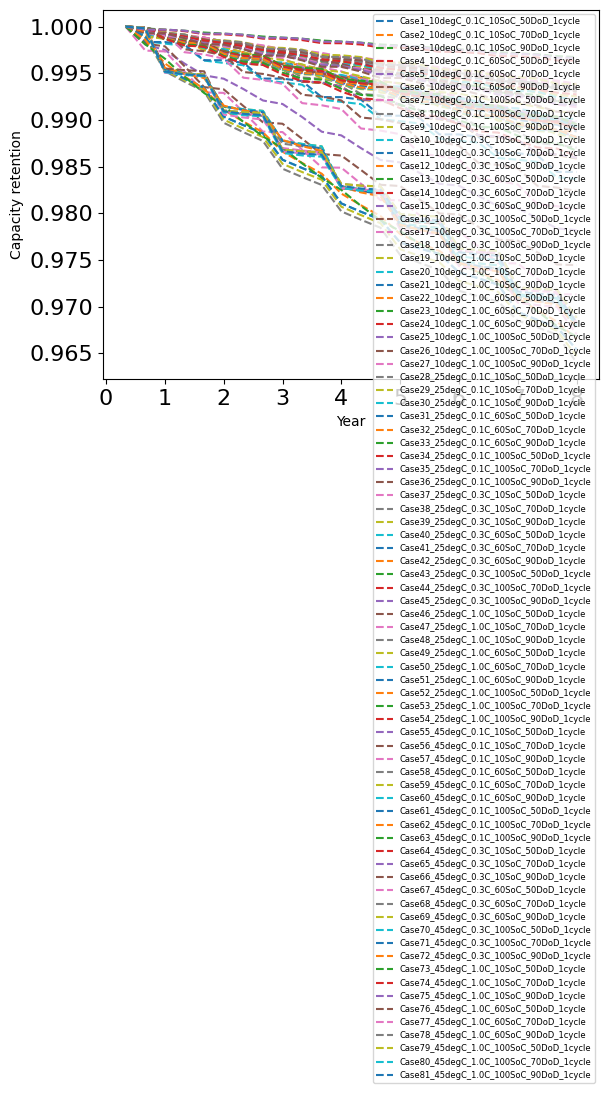

In [10]:
atol = 1e-6
rtol = 1e-6
cycles_per_day = 1
days_per_year = 1 #365
years_for_sim = 8
termination_capacity = 70
time_per_cycle = 24/cycles_per_day #in hours
soc_upper_cutoff = 1
soc_lower_cutoff = 0
max_dod = soc_upper_cutoff - soc_lower_cutoff
crate_ref = 0.1
period_charge_discharge = 5
period_rest = 60
safe_solver = pybamm.IDAKLUSolver() #options={"dt_max": 10}) #mode="safe", ,  dt_max= dt_max options={"dt_max": 5}

df_conditions = {}
df_conditions = pd.DataFrame(df_conditions)
simcase_list = []
experiment_list = []
no_steps_list = []

for n in range(len(df)):
    tempC_case = df["Temperature"][n]
    simcase = df["Case"][n]
    dod_case = df["DoD"][n]*0.01
    soc_case = df["SoC"][n]*0.01
    crate = df["C_rate"][n]
    
    parameter_values.update({"Ambient temperature [K]": 273.15 + tempC_case,
                            "Initial temperature [K]": 273.15 + tempC_case})

    t_soc0 = (1-soc_case)*60/crate_ref #time in minutes
    # exp0 = pybamm.Experiment([(f"Charge at {crate_ref}C until 4.2V", "Hold at 4.2V until 50 mA", f"Discharge at {crate_ref}C for {t_soc0} minutes")])
    # sim0 = pybamm.Simulation(model=model, parameter_values= parameter_values, experiment=exp0)
    # sol0 = sim0.solve()

    if soc_case == 1:
        model1 = model  #.set_initial_conditions_from(sol0)
    else:
        exp0 = pybamm.Experiment([(f"Charge at {crate_ref}C until 4.2V", "Hold at 4.2V until 50 mA", f"Discharge at {crate_ref}C for {t_soc0} minutes")])
        sim0 = pybamm.Simulation(model=model, parameter_values= parameter_values, experiment=exp0, solver=safe_solver)
        sol0 = sim0.solve()
        model1 = model.set_initial_conditions_from(sol0)
        

    discharge_time = int(60/crate*dod_case) # in minutes
    charge_time = int(60/crate*dod_case) # in minutes
    rest_time = int(time_per_cycle*60) - discharge_time - charge_time

    discharge_string = f"Discharge at {crate}C for {discharge_time} min or until 2.5V ({period_charge_discharge} minute period)"
    charge_string = f"Charge at {crate}C for {charge_time} min or until 4.2V ({period_charge_discharge} minute period)"
    rest_string = f"Rest for {rest_time} min ({period_rest} minute period)"


    if (soc_case-dod_case) >= soc_lower_cutoff:
        list_of_steps_auto = list([discharge_string, charge_string, rest_string])
    elif (soc_case+dod_case)<= soc_upper_cutoff:
        list_of_steps_auto = list([charge_string, discharge_string, rest_string])
    elif soc_case ==0.5 and dod_case > soc_case:
        discharge_to_soc_time = int(60/crate*(dod_case-soc_case))
        updated_rest_time = rest_time - discharge_to_soc_time
        discharge_to_soc_string = f"Discharge at {crate}C for {discharge_to_soc_time} minutes ({period_charge_discharge} minute period)"
        updated_rest_string = f"Rest for {updated_rest_time} minutes ({period_rest}) minute period)"
        
        list_of_steps_auto = list([discharge_string, charge_string, updated_rest_string]) # discharge_to_soc_string,
        
    steps_total = len(list_of_steps_auto)
        
    simcase_list.append(f"Case {simcase}: {tempC_case}degC, {soc_case*100}%SoC, {crate}C, {dod_case*100}%DoD, {cycles_per_day}cycles")
    no_steps_list.append(steps_total)
    experiment_list.append(list_of_steps_auto)
    exp1 = pybamm.Experiment(list_of_steps_auto*cycles_per_day*days_per_year*years_for_sim, termination=f"{termination_capacity}% capacity")
    sim1 = pybamm.Simulation(model=model1, parameter_values=parameter_values, experiment=exp1, solver=safe_solver)
    sol1 = sim1.solve(showprogress=True, ) #save_at_cycles=50
    print("Took", sol1.solve_time)
    
    Q1 = sim1.solution.summary_variables["Capacity [A.h]"]
    cycle1 = sim1.solution.summary_variables["Cycle number"]
    df2 = {}
    df2 = pd.DataFrame(df2)
    df2["Days"] =cycle1/(steps_total*cycles_per_day)
    df2["Capacity Retention"] = Q1/Q1[0]
    df2.to_csv(f"{current_directory}/paperstudies2026/Case{simcase}_{tempC_case}degC_{crate}C_{soc_case*100}SoC_{dod_case*100}DoD_{cycles_per_day}cycle.csv")

    plt.plot(cycle1/(steps_total*cycles_per_day)/days_per_year,Q1/Q1[0],"--", label =f"Case{simcase}_{tempC_case}degC_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD_{cycles_per_day}cycle")
    plt.legend(fontsize=6)

plt.xlabel("Year")
plt.ylabel("Capacity retention")
plt.xticks(fontsize =16)
plt.yticks(fontsize = 16)
plt.show()

df_conditions["simcase"] = simcase_list
df_conditions["Experiment"] = experiment_list
df_conditions["n_steps"] = no_steps_list

df_conditions.to_csv(f"{current_directory}/paperstudies2026/experiments1.csv")



In [45]:
soc_case

0.1

In [46]:
simcase

55

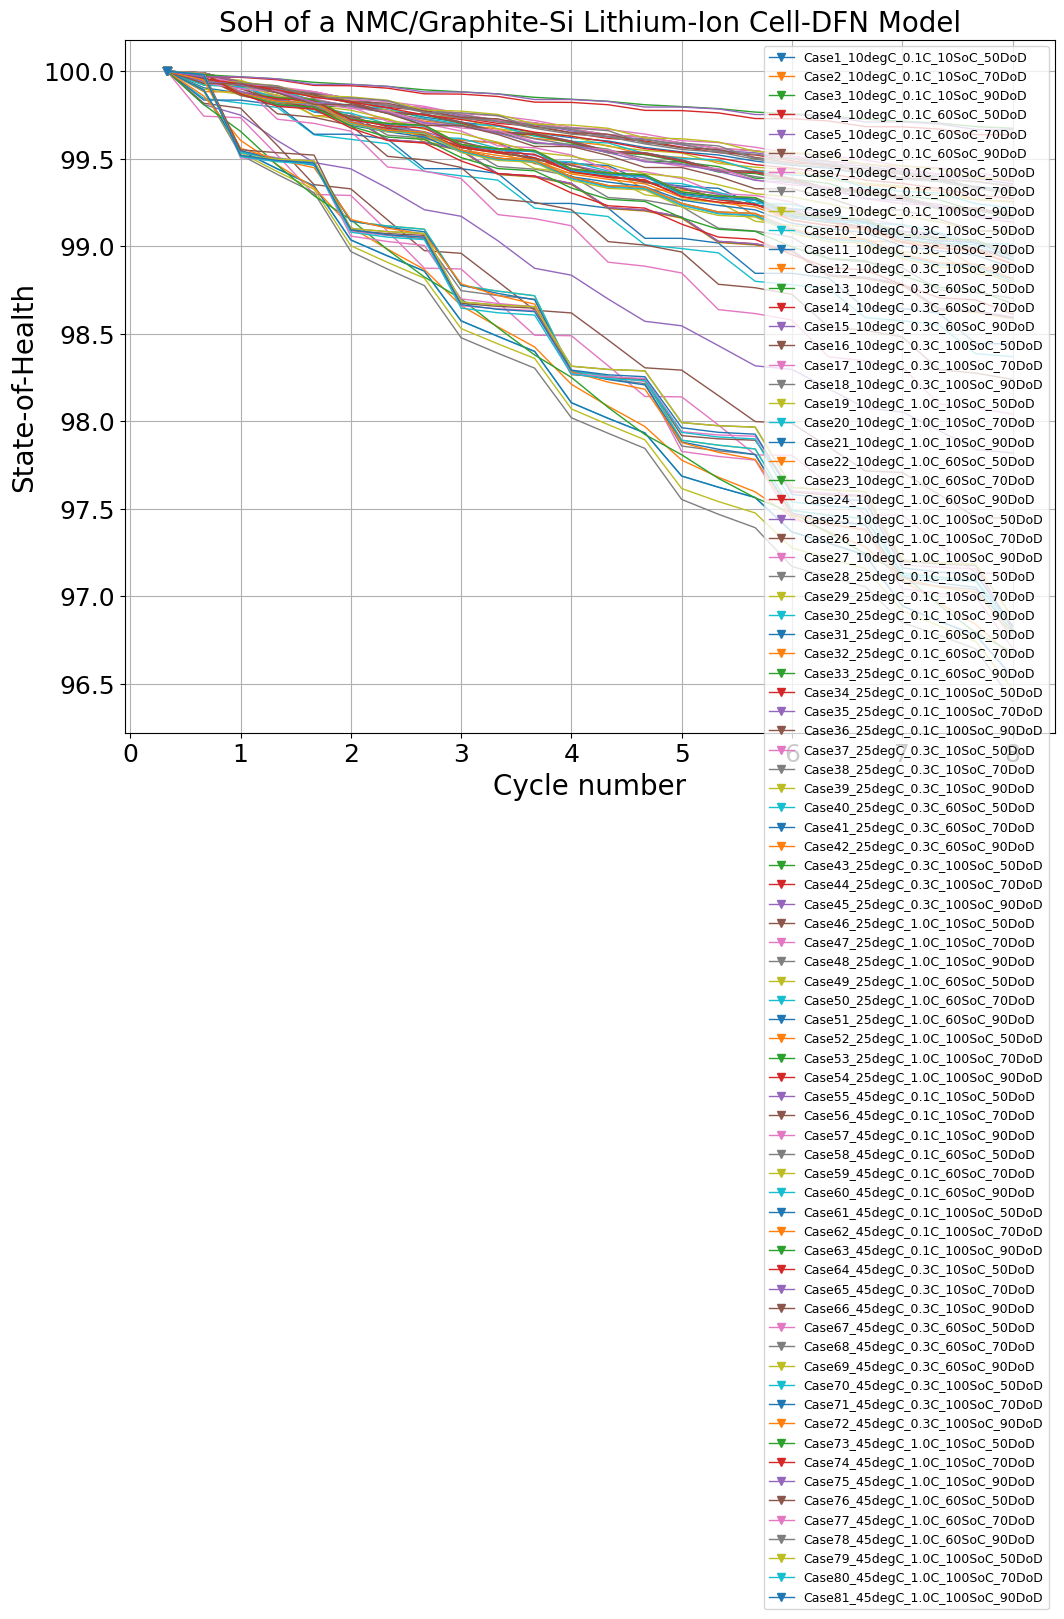

In [11]:
df3 = pd.read_csv(f"{current_directory}/paperstudies2026/Cases_for_ageing.csv")
cycles_per_day =1
plt.figure(figsize=(12,9))
b =0
for m in range(81):#,29,31,33,35,37,39,43,45,47,49,51,53,59,65,67,69,71,77,81]: #range(27,54):#: #range(5): #
    #b= b+1
    n = m
    tempC_case = df3["Temperature"][n]
    simcase = df3["Case"][n]
    dod_case = df3["DoD"][n]*0.01
    soc_case = df3["SoC"][n]*0.01
    crate = df3["C_rate"][n]
    df4 = pd.read_csv(f"{current_directory}/paperstudies2026/Case{simcase}_{tempC_case}degC_{crate}C_{soc_case*100}SoC_{dod_case*100}DoD_{cycles_per_day}cycle.csv")
    plt.plot(df4["Days"], df4["Capacity Retention"]*100,marker='v', markevery=50,linewidth=1, label =f"Case{simcase}_{tempC_case}degC_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD")

# for m in [29,31,35,37,39,43,45,47,51,53,54]: #33,49, #range(27,54):#: #range(5): #
#     b= b+1
#     n = m-1
#     tempC_case = df3["Temperature"][n]
#     simcase = df3["Case"][n]
#     dod_case = df3["DoD"][n]*0.01
#     soc_case = df3["SoC"][n]*0.01
#     crate = df3["C_rate"][n]
#     df4 = pd.read_csv(f"{current_directory}/ageingresults4dfn/Case{simcase}_{tempC_case}degC_{crate}C_{soc_case*100}SoC_{dod_case*100}DoD_{cycles_per_day}cycle.csv")
#     plt.plot(df4["Days"], df4["Capacity Retention"]*100,marker='*', markevery=50,linewidth=1, label =f"Case{b}_{tempC_case}degC_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD")

# for m in [59,65,67,69,71,77,81]: #range(27,54):#: #range(5): #
#     b= b+1
#     n = m-1
#     tempC_case = df3["Temperature"][n]
#     simcase = df3["Case"][n]
#     dod_case = df3["DoD"][n]*0.01
#     soc_case = df3["SoC"][n]*0.01
#     crate = df3["C_rate"][n]
#     df4 = pd.read_csv(f"{current_directory}/ageingresults4dfn/Case{simcase}_{tempC_case}degC_{crate}C_{soc_case*100}SoC_{dod_case*100}DoD_{cycles_per_day}cycle.csv")
#     plt.plot(df4["Days"], df4["Capacity Retention"]*100,marker='o', markevery=50,linewidth=1, label =f"Case{b}_{tempC_case}degC_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD")

plt.xlabel('Cycle number',fontsize=20)
plt.ylabel('State-of-Health',fontsize=20)
plt.title('SoH of a NMC/Graphite-Si Lithium-Ion Cell-DFN Model',fontsize=20)
#plt.ylim([70, 102])
#plt.xlim([-50, 1400])
plt.legend(fontsize=9)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(True)
plt.show()

In [ ]:
#sim1.plot()
#sol1.save("DFN_300cyl_fail-sol.pkl")

In [ ]:
safe_solver = pybamm.IDAKLUSolver(options={"dt_max": 5}) #mode="safe", ,  dt_max= dt_max, return_solution_if_failed_early=True, dt_max= 5.0,

parameter_values.update({"Ambient temperature [K]": 298.15,
                        "Initial temperature [K]": 298.15 })

sim1 = pybamm.Simulation(model=model, parameter_values=parameter_values, experiment=experiment0, solver=safe_solver) #
sol1 = sim1.solve(showprogress=True)
print("Took", sol1.solve_time)







Cycling:  46%|████▌     | 460/1000 [14:23<16:53,  1.88s/it]

Took 13 minutes, 19 seconds


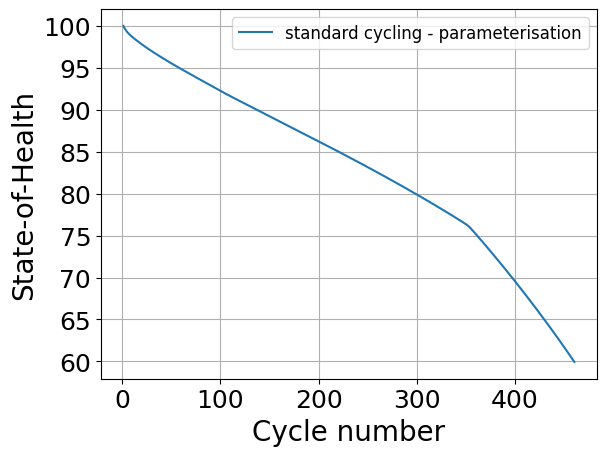

In [ ]:
Q1 = sim1.solution.summary_variables["Capacity [A.h]"]
cycle1 = sim1.solution.summary_variables["Cycle number"]
plt.plot(cycle1, 100*(Q1/Q1[0]), label = "standard cycling - parameterisation")
plt.legend(fontsize=12)

plt.xlabel('Cycle number',fontsize=20)
plt.ylabel('State-of-Health',fontsize=20)
# plt.title('SoH of a Lithium-Ion Cell-DFN Model',fontsize=20)
#plt.ylim([75, 101])
# #plt.xlim([-50, 500])
# plt.legend(fontsize=9)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(True)
# plt.show()

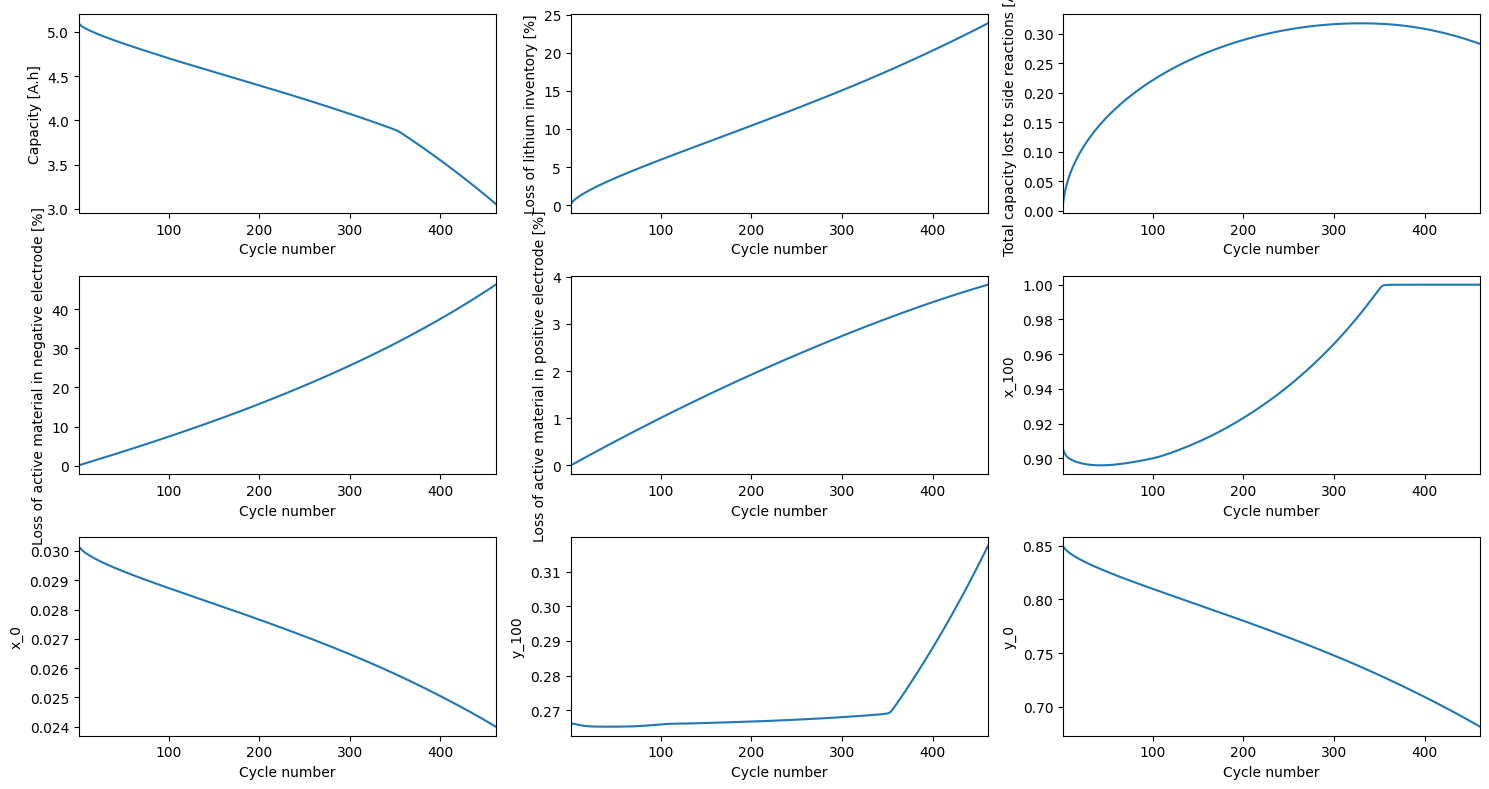

array([[<Axes: xlabel='Cycle number', ylabel='Capacity [A.h]'>,
        <Axes: xlabel='Cycle number', ylabel='Loss of lithium inventory [%]'>,
        <Axes: xlabel='Cycle number', ylabel='Total capacity lost to side reactions [A.h]'>],
       [<Axes: xlabel='Cycle number', ylabel='Loss of active material in negative electrode [%]'>,
        <Axes: xlabel='Cycle number', ylabel='Loss of active material in positive electrode [%]'>,
        <Axes: xlabel='Cycle number', ylabel='x_100'>],
       [<Axes: xlabel='Cycle number', ylabel='x_0'>,
        <Axes: xlabel='Cycle number', ylabel='y_100'>,
        <Axes: xlabel='Cycle number', ylabel='y_0'>]], dtype=object)

In [ ]:
pybamm.plot_summary_variables(sim1.solution)

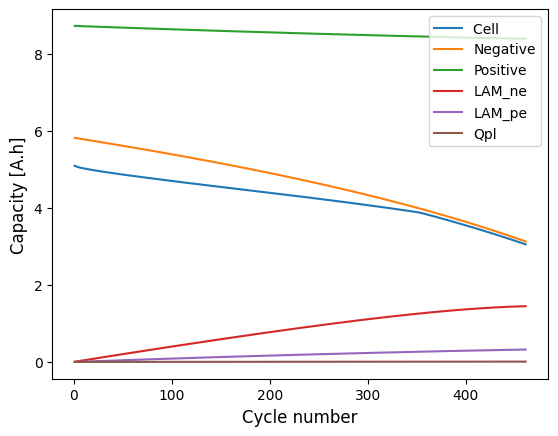

In [ ]:
Q1 = sim1.solution.summary_variables["Capacity [A.h]"]
Qnes = sim1.solution.summary_variables["Negative electrode capacity [A.h]"]
Qpes = sim1.solution.summary_variables["Positive electrode capacity [A.h]"]
Qpl=  sim1.solution.summary_variables["Loss of capacity to negative lithium plating [A.h]"]

mlam_n = sim1.solution.summary_variables['Loss of active material in negative electrode [%]']
mlam_p = sim1.solution.summary_variables['Loss of active material in positive electrode [%]']
cycle1s = sim1.solution.summary_variables["Cycle number"]

r1 = [a*b/100 for a, b in zip(mlam_n,Qnes)]
r2 = [a*b/100 for a, b in zip(mlam_p,Qpes)]
plt.plot(cycle1s, Q1, label="Cell ")
plt.plot(cycle1s, Qnes, label="Negative")
plt.plot(cycle1s, Qpes, label="Positive")
plt.plot(cycle1s, r1, label="LAM_ne")
plt.plot(cycle1s, r2, label="LAM_pe")
plt.plot(cycle1s, Qpl, label="Qpl")

plt.xlabel('Cycle number',fontsize=12)
plt.ylabel('Capacity [A.h]',fontsize=12)
plt.legend()
